# 🎬 Text Classification: Sentiment Analysis with RNNs

Welcome to this notebook on **Text Classification** — one of the most common and practical NLP tasks!

In our previous notebooks, we learned how to preprocess text and create word embeddings. Now, we'll put those concepts to work and build models that can **classify text** — specifically, to determine whether a movie review is **positive** or **negative**.

**Our Goal:** Build and compare two sentiment classifiers on the IMDB movie review dataset:
1. A simple **Bag of Embeddings** baseline (averaging word vectors)
2. A **Bidirectional LSTM** classifier (using sequential information)

**Notebook Outline:**
1. Setup and Prerequisites
2. The IMDB Dataset
3. Tokenization and Vocabulary
4. Loading Pre-trained GloVe Embeddings
5. Building the PyTorch DataLoaders
6. Model 1: Bag of Embeddings (Baseline)
7. Model 2: Bidirectional LSTM
8. Training and Evaluation
9. Testing on Custom Reviews
10. Conclusion

## Why Text Classification?

Text classification is the task of assigning a **category** (or label) to a piece of text. It's everywhere:

- **Sentiment Analysis:** Is this review positive or negative?
- **Spam Detection:** Is this email spam or not?
- **Topic Classification:** Is this article about sports, politics, or technology?
- **Intent Detection:** What is the user trying to do in this chatbot message?

Sentiment analysis is a great starting point because it's **binary** (positive vs. negative), intuitive, and has excellent datasets available.

## 1. Setup and Prerequisites

We'll use:
- **PyTorch**: For building and training our models
- **spaCy**: For text tokenization (consistent with our other notebooks)
- **gensim**: For loading pre-trained GloVe embeddings (from Notebook 02)
- **datasets (HuggingFace)**: For easy access to the IMDB dataset

In [1]:
# Install required packages
!pip install -q datasets gensim spacy
!python -m spacy download en_core_web_sm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

import spacy
import gensim.downloader as api
from datasets import load_dataset
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import random
import time

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print("\u2713 All libraries loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Using device: cuda
✓ All libraries loaded successfully!


## 2. The IMDB Dataset

The **IMDB dataset** is the "Hello World" of sentiment analysis. It contains 50,000 movie reviews from the Internet Movie Database, evenly split:
- **25,000 training reviews** (12,500 positive, 12,500 negative)
- **25,000 test reviews** (12,500 positive, 12,500 negative)

Each review is labeled as either **positive** (1) or **negative** (0).

We'll use the HuggingFace `datasets` library to load it — no manual downloading needed!

In [6]:
import os
import pandas as pd
from datasets import Dataset, DatasetDict

# Direct download URLs for the IMDB dataset in Parquet format
# This bypasses potential resolution issues with the datasets library
DATA_URLS = {
    'train': "https://huggingface.co/datasets/imdb/resolve/main/plain_text/train-00000-of-00001.parquet",
    'test': "https://huggingface.co/datasets/imdb/resolve/main/plain_text/test-00000-of-00001.parquet"
}

print("Loading IMDB dataset...")

# Download and load Parquet files
for split, url in DATA_URLS.items():
    filename = f"{split}.parquet"
    !wget -q {url} -O {filename}

train_df = pd.read_parquet("train.parquet")
test_df = pd.read_parquet("test.parquet")

# Convert to HuggingFace DatasetDict
imdb_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'test': Dataset.from_pandas(test_df)
})

# Cleanup and display stats
for split in DATA_URLS.keys():
    os.remove(f"{split}.parquet")

print(f"\u2713 Dataset loaded: {len(imdb_dataset['train']):,} train / {len(imdb_dataset['test']):,} test examples.")

Loading IMDB dataset...
✓ Dataset loaded: 25,000 train / 25,000 test examples.


## 3. Tokenization and Vocabulary

Before feeding text to a neural network, we need two steps:

1. **Tokenize**: Split each review into a list of words (tokens)
2. **Build a Vocabulary**: Map each unique word to an integer index

We'll use spaCy's tokenizer and add two special tokens:
- `<pad>` (index 0): Used to pad shorter sequences in a batch to the same length
- `<unk>` (index 1): Used for words not seen during training

We'll also **truncate** reviews to a maximum of 256 tokens to keep training fast.

> **Note:** Tokenizing 25,000 reviews takes 2-3 minutes. Be patient!

In [7]:
# Load spaCy tokenizer
nlp = spacy.load('en_core_web_sm')

MAX_LEN = 256  # Truncate reviews to this length

def tokenize(text, max_len=MAX_LEN):
    """Tokenize text using spaCy, lowercase, and truncate."""
    return [t.text.lower() for t in nlp.tokenizer(text)][:max_len]

# Tokenize all texts
print("Tokenizing training data (this takes ~2 minutes)...")
start = time.time()
train_tokens = [tokenize(text) for text in imdb_dataset['train']['text']]
print(f"  Done in {time.time() - start:.0f}s")

print("Tokenizing test data...")
start = time.time()
test_tokens = [tokenize(text) for text in imdb_dataset['test']['text']]
print(f"  Done in {time.time() - start:.0f}s")

# Show token statistics
lengths = [len(t) for t in train_tokens]
print(f"\nToken statistics (training):")
print(f"  Average length: {np.mean(lengths):.0f} tokens")
print(f"  Max length:     {max(lengths)} tokens")
print(f"  Min length:     {min(lengths)} tokens")

Tokenizing training data (this takes ~2 minutes)...
  Done in 32s
Tokenizing test data...
  Done in 28s

Token statistics (training):
  Average length: 194 tokens
  Max length:     256 tokens
  Min length:     11 tokens


In [8]:
class Vocabulary:
    """Maps words to integer indices and vice versa."""

    def __init__(self, min_freq=5):
        # Start with special tokens
        self.itos = {0: '<pad>', 1: '<unk>'}
        self.stoi = {'<pad>': 0, '<unk>': 1}
        self.min_freq = min_freq

    def build(self, token_lists):
        """Build vocabulary from a list of token lists."""
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        idx = len(self.itos)
        for word, count in counter.most_common():
            if count >= self.min_freq:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def numericalize(self, tokens):
        """Convert a list of tokens to a list of indices."""
        return [self.stoi.get(t, self.stoi['<unk>']) for t in tokens]

    def __len__(self):
        return len(self.itos)

# Build vocabulary from training data only
vocab = Vocabulary(min_freq=5)
vocab.build(train_tokens)
print(f"Vocabulary size: {len(vocab):,}")

# Example
example_tokens = train_tokens[0][:10]
example_indices = vocab.numericalize(example_tokens)
print(f"\nExample tokens:  {example_tokens}")
print(f"Example indices: {example_indices}")

Vocabulary size: 25,742

Example tokens:  ['i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video']
Example indices: [11, 1274, 11, 228, 1982, 18, 4454, 47, 64, 353]


## 4. Loading Pre-trained GloVe Embeddings

In Notebook 02, we learned that **word embeddings** are dense vector representations of words that capture semantic meaning. Words with similar meanings have similar vectors.

Instead of learning embeddings from scratch, we can use **pre-trained GloVe embeddings** — vectors trained on billions of words from Wikipedia and Gigaword. This gives our models a huge head start!

We'll load **GloVe 100-dimensional** vectors using `gensim`.

In [9]:
# Load pre-trained GloVe vectors
print("Downloading GloVe embeddings (this may take a minute)...")
glove = api.load('glove-wiki-gigaword-100')
EMB_DIM = 100
print(f"Loaded GloVe with {len(glove):,} words, {EMB_DIM} dimensions")

def create_embedding_matrix(vocab, glove_model, emb_dim):
    """Create an embedding matrix: row i = GloVe vector for word i in vocab."""
    matrix = torch.zeros(len(vocab), emb_dim)
    found = 0

    for idx in range(2, len(vocab)):  # Skip <pad> (0) and <unk> (1)
        word = vocab.itos[idx]
        if word in glove_model:
            matrix[idx] = torch.tensor(glove_model[word], dtype=torch.float32)
            found += 1
        else:
            # Random initialization for words not in GloVe
            matrix[idx] = torch.randn(emb_dim) * 0.1

    # Set <unk> to the mean of all found vectors
    if found > 0:
        matrix[1] = matrix[2:].mean(dim=0)

    return matrix, found

embedding_matrix, found = create_embedding_matrix(vocab, glove, EMB_DIM)
print(f"Found {found}/{len(vocab)} ({100*found/len(vocab):.1f}%) words in GloVe")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded GloVe with 400,000 words, 100 dimensions
Found 23755/25742 (92.3%) words in GloVe
Embedding matrix shape: torch.Size([25742, 100])


## 5. Building the PyTorch DataLoaders

Now we need to create PyTorch `Dataset` and `DataLoader` objects. The key challenge is **padding**: since reviews have different lengths, we need to pad shorter ones with `<pad>` tokens so all reviews in a batch have the same length.

We'll also split our training data into **training** (80%) and **validation** (20%) sets.

In [23]:
PAD_IDX = vocab.stoi['<pad>']

class SentimentDataset(Dataset):
    """PyTorch Dataset for sentiment analysis."""

    def __init__(self, token_lists, labels, vocab):
        self.samples = []
        for tokens, label in zip(token_lists, labels):
            indices = vocab.numericalize(tokens)
            self.samples.append((
                torch.tensor(indices, dtype=torch.long),
                label
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

    def __getitems__(self, indices):
        return [self.samples[i] for i in indices]

def collate_fn(batch):
    """Custom collate function to pad sequences in a batch."""
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts])
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    labels = torch.tensor(labels, dtype=torch.float)
    return texts_padded, labels, lengths

# Create datasets
full_train_dataset = SentimentDataset(train_tokens, imdb_dataset['train']['label'], vocab)
test_dataset = SentimentDataset(test_tokens, imdb_dataset['test']['label'], vocab)

# Split train into train/val (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate_fn)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

# Quick check
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Text:    {batch[0].shape}")
print(f"  Labels:  {batch[1].shape}")
print(f"  Lengths: {batch[2].shape}")

Training batches:   313
Validation batches: 79
Test batches:       391

Batch shapes:
  Text:    torch.Size([64, 256])
  Labels:  torch.Size([64])
  Lengths: torch.Size([64])


## 6. Model 1: Bag of Embeddings (Baseline)

Our first model is intentionally simple. It serves as a **baseline** — a minimum standard that more complex models should beat.

**How it works:**
1. **Embed** each word in the review using our GloVe vectors
2. **Average** all word vectors to get a single vector representing the entire review
3. Pass this average through a **Linear layer** to predict positive/negative

This is essentially a "Bag of Words" model, but with embeddings instead of counts. It **ignores word order** entirely — "not good" and "good not" would produce the same vector.

```
     Input:   "this movie was great"
                    |
          Embedding Layer (GloVe)
     [0.2, -0.1, ...] [0.5, 0.3, ...] ...
                    |
            Average Pooling
          -> single d-dim vector
                    |
           Linear -> sigmoid
            -> P(positive)
```

In [24]:
class BagOfEmbeddings(nn.Module):
    """Simple baseline: average word embeddings, then classify."""

    def __init__(self, pretrained_embeddings, output_dim, pad_idx):
        super().__init__()

        vocab_size, emb_dim = pretrained_embeddings.shape

        # Initialize embedding layer with pre-trained GloVe vectors
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(pretrained_embeddings)

        self.fc = nn.Linear(emb_dim, output_dim)

    def forward(self, text, lengths):
        # text: [batch_size, seq_len]

        # 1. Get embeddings
        embedded = self.embedding(text)  # [batch_size, seq_len, emb_dim]

        # 2. Create mask to ignore padding
        mask = (text != 0).unsqueeze(-1).float()  # [batch_size, seq_len, 1]

        # 3. Masked average pooling
        summed = (embedded * mask).sum(dim=1)  # [batch_size, emb_dim]
        averaged = summed / lengths.unsqueeze(1).float().to(summed.device)

        # 4. Classify
        return self.fc(averaged).squeeze(-1)  # [batch_size]

# Instantiate the model
boe_model = BagOfEmbeddings(
    embedding_matrix, output_dim=1, pad_idx=PAD_IDX
).to(device)

# Count parameters
total_params = sum(p.numel() for p in boe_model.parameters())
trainable_params = sum(p.numel() for p in boe_model.parameters() if p.requires_grad)
print(f"Bag of Embeddings:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Bag of Embeddings:
  Total parameters:     2,574,301
  Trainable parameters: 2,574,301


## 7. Model 2: Bidirectional LSTM Classifier

Now for the real deal! Our LSTM model **preserves word order** and can capture sequential patterns like "not good" vs. "good".

**How it works:**
1. **Embed** each word using GloVe vectors
2. Feed the sequence through a **Bidirectional LSTM**
   - The forward LSTM reads left-to-right
   - The backward LSTM reads right-to-left
3. **Concatenate** the final hidden states from both directions
4. Pass through a **Linear layer** to predict positive/negative

**Why Bidirectional?** A forward-only LSTM's final hidden state is most influenced by the *last* words. A bidirectional LSTM gives equal "access" to the beginning and end of the review.

```
     Input:   "this movie was great"
                    |
          Embedding Layer (GloVe)
                    |
           Bidirectional LSTM
        (reads forward AND backward)
                    |
     Concat(final_fwd, final_bwd)
                    |
        Linear -> sigmoid -> P(positive)
```

### Packed Sequences

One important technical detail: since reviews have different lengths, we use **packed sequences** (`pack_padded_sequence`). This tells the LSTM to skip over padding tokens, making training both faster and more accurate.

In [25]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM for sentiment classification."""

    def __init__(self, pretrained_embeddings, hidden_dim, output_dim,
                 n_layers, dropout, pad_idx):
        super().__init__()

        vocab_size, emb_dim = pretrained_embeddings.shape

        # 1. Embedding layer (initialized with GloVe)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.embedding.weight.data.copy_(pretrained_embeddings)

        # 2. Bidirectional LSTM
        self.lstm = nn.LSTM(
            emb_dim, hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )

        # 3. Classification head
        # hidden_dim * 2 because bidirectional concatenates both directions
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, lengths):
        # text: [batch_size, seq_len]

        # 1. Get embeddings
        embedded = self.dropout(self.embedding(text))
        # [batch_size, seq_len, emb_dim]

        # 2. Pack the sequence (skip padding in LSTM computation)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(),
            batch_first=True, enforce_sorted=False
        )

        # 3. Run through LSTM
        packed_output, (hidden, cell) = self.lstm(packed)
        # hidden: [n_layers * 2, batch_size, hidden_dim]

        # 4. Concatenate final forward and backward hidden states
        # hidden[-2] = last layer, forward direction
        # hidden[-1] = last layer, backward direction
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        # combined: [batch_size, hidden_dim * 2]

        combined = self.dropout(combined)

        # 5. Classify
        return self.fc(combined).squeeze(-1)  # [batch_size]

# Hyperparameters
HIDDEN_DIM = 128
N_LAYERS = 2
DROPOUT = 0.5

lstm_model = BiLSTMClassifier(
    embedding_matrix, HIDDEN_DIM, output_dim=1,
    n_layers=N_LAYERS, dropout=DROPOUT, pad_idx=PAD_IDX
).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters())
trainable_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"BiLSTM Classifier:")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

BiLSTM Classifier:
  Total parameters:     3,205,241
  Trainable parameters: 3,205,241


## 8. Training and Evaluation

Now we train both models and compare them! We'll use:
- **BCEWithLogitsLoss**: Binary cross-entropy with built-in sigmoid (numerically stable)
- **Adam optimizer**: Adaptive learning rate
- **10 epochs**: Enough to see convergence on this dataset

In [26]:
def train_epoch(model, loader, optimizer, criterion):
    """Train for one epoch."""
    model.train()
    epoch_loss = 0
    epoch_acc = 0

    for texts, labels, lengths in loader:
        texts = texts.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        predictions = model(texts, lengths)
        loss = criterion(predictions, labels)

        # Accuracy: prediction > 0 means positive (before sigmoid)
        acc = ((predictions > 0).float() == labels).float().mean()

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


def evaluate(model, loader, criterion):
    """Evaluate on a dataset."""
    model.eval()
    epoch_loss = 0
    epoch_acc = 0

    with torch.no_grad():
        for texts, labels, lengths in loader:
            texts = texts.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            predictions = model(texts, lengths)
            loss = criterion(predictions, labels)
            acc = ((predictions > 0).float() == labels).float().mean()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


def train_model(model, name, train_loader, val_loader, n_epochs=5, lr=1e-3):
    """Full training loop with logging."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    print(f"\n{'='*60}")
    print(f" Training: {name}")
    print(f"{'='*60}")

    for epoch in range(n_epochs):
        start = time.time()

        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(
            model, val_loader, criterion)

        elapsed = time.time() - start

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{name}.pt')

        print(f"Epoch {epoch+1:02}/{n_epochs} | "
              f"Time: {elapsed:.0f}s | "
              f"Train Loss: {train_loss:.3f} Acc: {train_acc:.3f} | "
              f"Val Loss: {val_loss:.3f} Acc: {val_acc:.3f}")

    # Load best model
    model.load_state_dict(torch.load(f'best_{name}.pt'))
    return history

In [35]:
N_EPOCHS = 5

# Train Bag of Embeddings
boe_history = train_model(
    boe_model, 'boe', train_loader, val_loader, N_EPOCHS)

# Train BiLSTM
lstm_history = train_model(
    lstm_model, 'bilstm', train_loader, val_loader, N_EPOCHS)


 Training: boe
Epoch 01/5 | Time: 1s | Train Loss: 0.136 Acc: 0.958 | Val Loss: 0.278 Acc: 0.883
Epoch 02/5 | Time: 1s | Train Loss: 0.123 Acc: 0.963 | Val Loss: 0.280 Acc: 0.883
Epoch 03/5 | Time: 1s | Train Loss: 0.111 Acc: 0.968 | Val Loss: 0.282 Acc: 0.884
Epoch 04/5 | Time: 1s | Train Loss: 0.101 Acc: 0.972 | Val Loss: 0.286 Acc: 0.884
Epoch 05/5 | Time: 1s | Train Loss: 0.091 Acc: 0.976 | Val Loss: 0.292 Acc: 0.881

 Training: bilstm
Epoch 01/5 | Time: 13s | Train Loss: 0.201 Acc: 0.927 | Val Loss: 0.294 Acc: 0.882
Epoch 02/5 | Time: 14s | Train Loss: 0.161 Acc: 0.942 | Val Loss: 0.345 Acc: 0.884
Epoch 03/5 | Time: 14s | Train Loss: 0.141 Acc: 0.950 | Val Loss: 0.327 Acc: 0.880
Epoch 04/5 | Time: 14s | Train Loss: 0.120 Acc: 0.957 | Val Loss: 0.352 Acc: 0.878
Epoch 05/5 | Time: 13s | Train Loss: 0.103 Acc: 0.965 | Val Loss: 0.396 Acc: 0.880


### 8.1. Visualizing Training Progress

Let's plot the training curves to compare our two models.

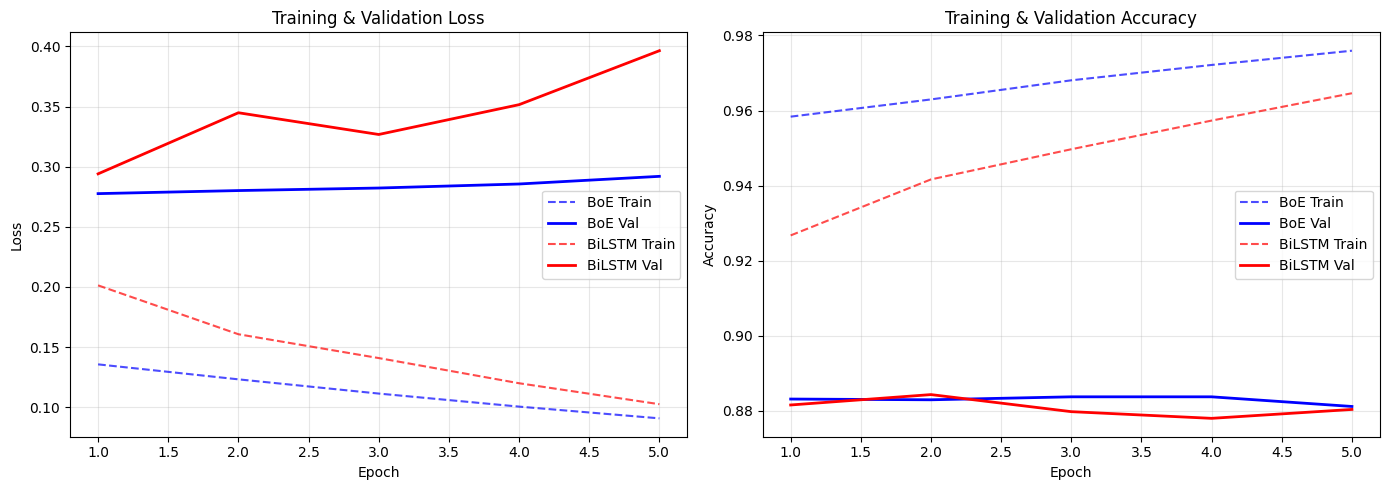

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, N_EPOCHS + 1)

# Loss plot
axes[0].plot(epochs_range, boe_history['train_loss'],
             'b--', label='BoE Train', alpha=0.7)
axes[0].plot(epochs_range, boe_history['val_loss'],
             'b-', label='BoE Val', linewidth=2)
axes[0].plot(epochs_range, lstm_history['train_loss'],
             'r--', label='BiLSTM Train', alpha=0.7)
axes[0].plot(epochs_range, lstm_history['val_loss'],
             'r-', label='BiLSTM Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, boe_history['train_acc'],
             'b--', label='BoE Train', alpha=0.7)
axes[1].plot(epochs_range, boe_history['val_acc'],
             'b-', label='BoE Val', linewidth=2)
axes[1].plot(epochs_range, lstm_history['train_acc'],
             'r--', label='BiLSTM Train', alpha=0.7)
axes[1].plot(epochs_range, lstm_history['val_acc'],
             'r-', label='BiLSTM Val', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Final evaluation on the held-out test set
criterion = nn.BCEWithLogitsLoss()

boe_test_loss, boe_test_acc = evaluate(boe_model, test_loader, criterion)
lstm_test_loss, lstm_test_acc = evaluate(lstm_model, test_loader, criterion)

print("=" * 55)
print(" Final Test Results")
print("=" * 55)
print(f"{'Model':<25} {'Test Loss':>12} {'Test Acc':>12}")
print("-" * 55)
print(f"{'Bag of Embeddings':<25} {boe_test_loss:>12.3f} {boe_test_acc:>11.1%}")
print(f"{'Bidirectional LSTM':<25} {lstm_test_loss:>12.3f} {lstm_test_acc:>11.1%}")
print("-" * 55)

 Final Test Results
Model                        Test Loss     Test Acc
-------------------------------------------------------
Bag of Embeddings                0.318       86.5%
Bidirectional LSTM               0.341       86.2%
-------------------------------------------------------


## 9. Testing on Custom Reviews

Let's use our trained models to classify some custom movie reviews!

In [38]:
def predict_sentiment(model, text, vocab, device):
    """Predict sentiment for a single text."""
    model.eval()
    tokens = tokenize(text)
    indices = vocab.numericalize(tokens)
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(indices)]).to(device)

    with torch.no_grad():
        prediction = model(tensor, length)

    prob = torch.sigmoid(prediction).item()
    sentiment = "Positive" if prob > 0.5 else "Negative"
    return sentiment, prob

# Custom test sentences
test_reviews = [
    "This movie was absolutely fantastic! Great acting and beautiful cinematography.",
    "Terrible film. The plot was boring and the acting was wooden. Waste of time.",
    "It was okay, nothing special. Some good moments but overall forgettable.",
    "I did not expect much, but this turned out to be one of the best films of the year!",
    "The special effects were great but the story made no sense and the dialogue was awful.",
]

print("=" * 70)
print(" Custom Review Predictions")
print("=" * 70)

for review in test_reviews:
    boe_sent, boe_prob = predict_sentiment(boe_model, review, vocab, device)
    lstm_sent, lstm_prob = predict_sentiment(lstm_model, review, vocab, device)

    print(f'\nReview: "{review}"')
    print(f"  BoE:    {boe_sent:>8} (confidence: {boe_prob:.3f})")
    print(f"  BiLSTM: {lstm_sent:>8} (confidence: {lstm_prob:.3f})")

 Custom Review Predictions

Review: "This movie was absolutely fantastic! Great acting and beautiful cinematography."
  BoE:    Positive (confidence: 1.000)
  BiLSTM: Positive (confidence: 0.994)

Review: "Terrible film. The plot was boring and the acting was wooden. Waste of time."
  BoE:    Negative (confidence: 0.000)
  BiLSTM: Negative (confidence: 0.007)

Review: "It was okay, nothing special. Some good moments but overall forgettable."
  BoE:    Negative (confidence: 0.000)
  BiLSTM: Negative (confidence: 0.015)

Review: "I did not expect much, but this turned out to be one of the best films of the year!"
  BoE:    Positive (confidence: 0.811)
  BiLSTM: Positive (confidence: 0.853)

Review: "The special effects were great but the story made no sense and the dialogue was awful."
  BoE:    Negative (confidence: 0.000)
  BiLSTM: Negative (confidence: 0.036)


## 10. Conclusion and Next Steps

Congratulations! You've built and compared two complete sentiment classifiers.

### What We Learned

| Model | Key Idea | Strength | Weakness |
| --- | --- | --- | --- |
| **Bag of Embeddings** | Average all word vectors | Simple, fast, surprisingly effective | Ignores word order |
| **Bidirectional LSTM** | Process words sequentially | Captures sequential patterns | Slower, more parameters |

### Key Takeaways

1. **Pre-trained embeddings are powerful.** Using GloVe gave both models a huge advantage — the BoE baseline already achieves good accuracy just by averaging GloVe vectors.

2. **Word order matters.** The BiLSTM outperforms the BoE baseline because it can distinguish "not good" from "good." Sequential models capture negation, intensification, and other word-order-dependent patterns.

3. **Simple baselines are important.** Always start with a simple model. If your complex model can't beat it, something is wrong.